# ENVIRONMENTAL DATA OVERVIEW
This notebook aims to explore the environmental data and prepare it for further analysis and machine learning.

In [282]:
#we import all they key libraries needed in this notebook
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

## net CDF data files and visualizations on earth map
Files needed in ./nc folder:
- woa23_all_o00_01.nc
- woa23_decav_t00_01.nc
- woa23_all_p00_01.nc
- woa23_all_n00_01.n


In [283]:
#paths to the net CDF files that should be sotred in the ./nc folder
mapsnc = {
    "o": "woa23_all_o00_01.nc",
    "t": "woa23_decav_t00_01.nc",
    "p": "woa23_all_p00_01.nc",
    "n":"woa23_all_n00_01.nc"
}

mapsds = dict()
#we can open each file
for feature, path in mapsnc.items():
    temp_ds = xr.open_dataset("./nc/"+path, decode_times=False)
    mapsds[feature] = temp_ds

#temp_path = "woa23_decav_t00_01.nc"
#ds = xr.open_dataset("./nc/"+temp_path, decode_times=False)

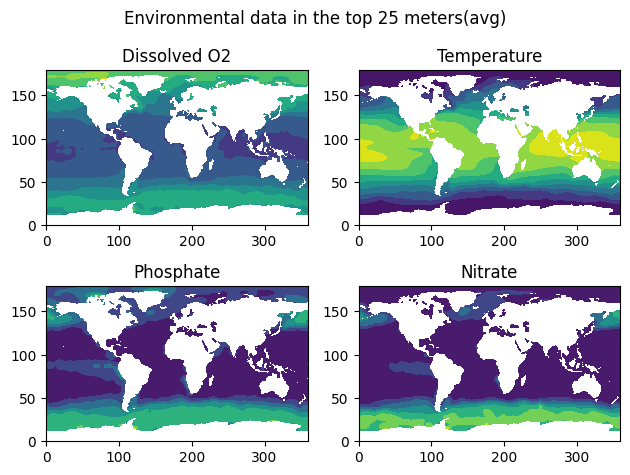

In [284]:
#the plot and plot data for visualization
figure, axis = plt.subplots(2, 2)
map_plot_data = {
    "o": ("Dissolved O2", (0,0)),
    "t": ("Temperature", (0,1)),
    "p": ("Phosphate", (1,0)),
    "n": ("Nitrate", (1,1))
}

#we want to average out the data according to the depth in the desired range
for feature, feat_ds in mapsds.items():
    mapsds[feature] = feat_ds['{0}_an'.format(feature)].sel(depth=slice(0, 25)).isel(time=0).mean(dim='depth')

    #then the data can be plotted
    title = map_plot_data[feature][0]
    x,y = map_plot_data[feature][1][0],map_plot_data[feature][1][1]
    axis[x,y].contourf(mapsds[feature])
    axis[x,y].set_title(title)

#plt.colorbar()
figure.suptitle("Environmental data in the top 25 meters(avg)")
plt.tight_layout()
plt.show()

## Preparing csv data for further analysis
### IMPORTANT:
Download the following files into the folder csv as they are necessary for the next step:
- ***woa23_all_o00mn01.csv***
- ***woa23_decav_t00mn01.csv***
- ***woa23_all_p00mn01.csv***
- ***woa23_all_n00mn01.csv***

If we take a look at a csv tables provided by the source a few key features stand out that need to be addressed before any kind of machine learning can be done on the data. 
#### Tables are about a specific feature:
There is a table for each feature. Thus, we would have to join them if possible to create 1 unified table with the environmental data.
#### Null values:
There is an abundance of data, yet null values are still present in some places, thus we would neet to check for them and find a way to deal with them.
#### Data at different depths:
Each dataset provides data for different depths, which can be useful, but for the purposes of this project it was decided, that averaged data should be used from the first 25m of depth. So, we need to keep only the columns for coordinates and averaged data from those depths.

There might be more things that we will notice as we conduct further analysis of each feature in the dataset.

In [285]:
#we have several files for each feature so it makes sense to use a loop
tables = {
    "O2": "woa23_all_o00mn01.csv",
    "T": "woa23_decav_t00mn01.csv",
    "P": "woa23_all_p00mn01.csv",
    "N":"woa23_all_n00mn01.csv"
}

#the output is long, might require view as scrollable element
for feature, table in tables.items():
    print("FEATURE: {0}\n".format(feature))
    #initial frame is loaded into memory
    frame = pd.read_csv("./csv/"+table, skiprows=1)
    print(frame.columns)

    #the columns we want to average for the depth
    depth_cols = [" AND VALUES AT DEPTHS (M):0", "5","10","15","20","25"]
    #we obrain average values for depth
    avg = sum([frame[el] for el in depth_cols])/(np.ones(frame.shape[0])*6)

    #we join the columns we actually want to use
    cord = frame[["#COMMA SEPARATED LATITUDE"," LONGITUDE"]]
    df_temp = pd.concat([cord,avg], axis=1)
    #the names should be changed to fit the goals and to make working with them easier in the future
    new_names = {'#COMMA SEPARATED LATITUDE': 'lat', ' LONGITUDE': 'longt', 0: feature}#will replace data with feature name
    df_temp = df_temp.rename(columns=new_names)

    #we show the results
    print("TABLE HEAD AFTER TRANSOFRMATIONS:\n{0}".format(df_temp.head()))
    print("DATASET SHAPE: {0}".format(df_temp.shape))
    print("DATASET INFO:\n")
    #it should be 
    df_temp.info()
    print(df_temp.describe())
    df_temp.to_csv("csv/features/{0}.csv".format(feature))



FEATURE: O2

Index(['#COMMA SEPARATED LATITUDE', ' LONGITUDE',
       ' AND VALUES AT DEPTHS (M):0', '5', '10', '15', '20', '25', '30', '35',
       ...
       '4600', '4700', '4800', '4900', '5000', '5100', '5200', '5300', '5400',
       '5500'],
      dtype='object', length=104)
TABLE HEAD AFTER TRANSOFRMATIONS:
    lat  longt          O2
0 -77.5 -178.5  363.257667
1 -77.5 -177.5  379.909333
2 -77.5 -176.5  343.680667
3 -77.5 -175.5  364.647500
4 -77.5 -174.5  355.757167
DATASET SHAPE: (32505, 3)
DATASET INFO:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32505 entries, 0 to 32504
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   lat     32505 non-null  float64
 1   longt   32505 non-null  float64
 2   O2      29299 non-null  float64
dtypes: float64(3)
memory usage: 762.0 KB
                lat         longt            O2
count  32505.000000  32505.000000  29299.000000
mean      -6.709906     -5.523504    260.462001
st

## Output:
As output of this step the features folder should contain 4 disctinct files one for each environmental feature with 3 columns: latitude, longtitude and the average data for the first 25 meters.

## Next step:
Now we have a table for each feature, but we want just 1 with all the environmental data in it. Thus, for each coordinate we want to merge the tables so that we have only 2 coordinate columns left and 4 columns of the environmental data.

In [286]:
#TODO